In [4]:
!pip install -q datasets transformers evaluate accelerate gensim contractions gradio streamlit pyngrok
!pip install -q tensorflow

import os, re, json, random, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

print("TF:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
from datasets import load_dataset

raw = load_dataset("google-research-datasets/go_emotions", "simplified")
print(raw)

label_names = raw["train"].features["labels"].feature.names
print(f"Number of raw emotion labels: {len(label_names)}")
print(label_names)


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
Number of raw emotion labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [6]:
df_train_raw = raw["train"].to_pandas()
df_val_raw   = raw["validation"].to_pandas()
df_test_raw  = raw["test"].to_pandas()

print(df_train_raw.shape, df_val_raw.shape, df_test_raw.shape)
df_train_raw.head()


(43410, 3) (5426, 3) (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


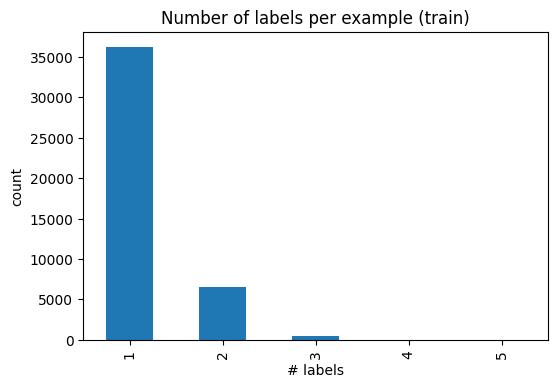

In [7]:
# Quick look at label cardinality (GoEmotions is multi-label)
n_labels_per_example = df_train_raw["labels"].apply(len)
print(n_labels_per_example.value_counts().sort_index())

plt.figure(figsize=(6,4))
n_labels_per_example.value_counts().sort_index().plot(kind="bar")
plt.title("Number of labels per example (train)")
plt.xlabel("# labels"); plt.ylabel("count")
plt.show()


##  Map Raw Labels

In [8]:
EKMAN_MAPPING = {
    "anger":    ["anger", "annoyance", "disapproval"],
    "disgust":  ["disgust"],
    "fear":     ["fear", "nervousness"],
    "joy":      ["admiration", "amusement", "approval", "caring", "desire",
                 "excitement", "gratitude", "joy", "love", "optimism",
                 "pride", "relief"],
    "sadness":  ["disappointment", "embarrassment", "grief", "remorse", "sadness"],
    "surprise": ["confusion", "curiosity", "realization", "surprise"],
    # "neutral" is intentionally dropped -- not one of our 6 target classes
}

TARGET_EMOTIONS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

# raw label id -> target emotion (or None)
raw_to_target = {}
for target, raw_group in EKMAN_MAPPING.items():
    for raw_name in raw_group:
        raw_to_target[label_names.index(raw_name)] = target

def map_labels_to_single_target(label_ids):
    """Map a list of raw GoEmotions label ids to a single one of the 6 target
    emotions. Returns None if the example is ambiguous (maps to >1 distinct
    target classes), or has no mapped label (e.g. only 'neutral')."""
    mapped = {raw_to_target[i] for i in label_ids if i in raw_to_target}
    if len(mapped) == 1:
        return next(iter(mapped))
    return None

def build_6class_df(df):
    out = df.copy()
    out["emotion"] = out["labels"].apply(map_labels_to_single_target)
    out = out.dropna(subset=["emotion"]).reset_index(drop=True)
    return out[["text", "emotion"]]

df_train = build_6class_df(df_train_raw)
df_val   = build_6class_df(df_val_raw)
df_test  = build_6class_df(df_test_raw)

print("Train:", df_train.shape, " Val:", df_val.shape, " Test:", df_test.shape)
df_train["emotion"].value_counts()


Train: (28104, 2)  Val: (3527, 2)  Test: (3539, 2)


emotion
joy         15809
anger        4590
surprise     4160
sadness      2455
fear          566
disgust       524
Name: count, dtype: int64

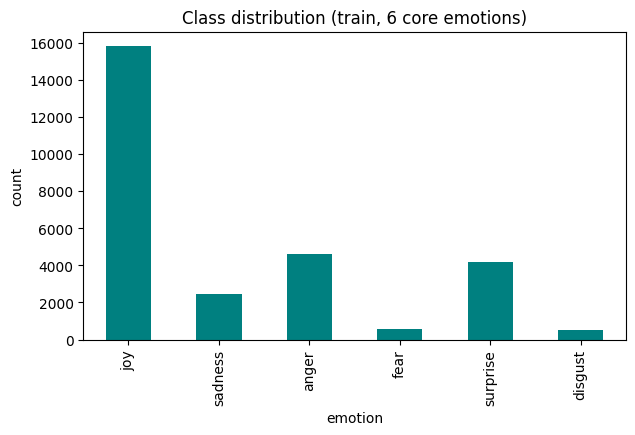

In [9]:
plt.figure(figsize=(7,4))
df_train["emotion"].value_counts().reindex(TARGET_EMOTIONS).plot(kind="bar", color="teal")
plt.title("Class distribution (train, 6 core emotions)")
plt.ylabel("count")
plt.show()


## 3. Clean, Tokenize & Pad Sequences

In [10]:
import contractions

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for d in (df_train, df_val, df_test):
    d["clean_text"] = d["text"].apply(clean_text)

df_train[["text", "clean_text", "emotion"]].head()


,text,clean_text,emotion
0,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,anger
1,To make her feel threatened,to make her feel threatened,fear
2,Dirty Southern Wankers,dirty southern wankers,anger
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,omg peyton is not good enough to help us in th...,surprise
4,Yes I heard abt the f bombs! That has to be wh...,yes i heard about the f bombs that has to be w...,joy


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN   = 40

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["clean_text"])

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(df_train["clean_text"])
X_val   = to_padded(df_val["clean_text"])
X_test  = to_padded(df_test["clean_text"])

# IMPORTANT FIX: sklearn's LabelEncoder sorts classes ALPHABETICALLY, which does
# NOT match the order of TARGET_EMOTIONS (joy, sadness, anger, fear, surprise,
# disgust). That mismatch silently scrambled the per-class report / confusion
# matrix labels in the previous version (overall accuracy/F1 were still correct,
# but the "which class is which" labels were wrong). We fix it by mapping labels
# to integers explicitly in TARGET_EMOTIONS order, and reuse the same mapping
# for the HuggingFace/DistilBERT model later so every model agrees on class ids.
label2id = {name: i for i, name in enumerate(TARGET_EMOTIONS)}
id2label = {i: name for name, i in label2id.items()}

y_train = df_train["emotion"].map(label2id).to_numpy()
y_val   = df_val["emotion"].map(label2id).to_numpy()
y_test  = df_test["emotion"].map(label2id).to_numpy()

NUM_CLASSES = len(TARGET_EMOTIONS)
VOCAB_SIZE  = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("Vocab size used:", VOCAB_SIZE)
print("Classes (id -> name):", id2label)


X_train: (28104, 40)  y_train: (28104,)
Vocab size used: 19863
Classes (id -> name): {0: 'joy', 1: 'sadness', 2: 'anger', 3: 'fear', 4: 'surprise', 5: 'disgust'}


In [12]:
# Class weights to handle imbalance (GoEmotions is skewed toward 'joy')
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
class_weight_dict


{0: np.float64(0.2962869251692074),
 1: np.float64(1.9079429735234217),
 2: np.float64(1.020479302832244),
 3: np.float64(8.275618374558304),
 4: np.float64(1.1259615384615385),
 5: np.float64(8.938931297709924)}

In [14]:
import os

GLOVE_DIR = "/kaggle/working/glove"
os.makedirs(GLOVE_DIR, exist_ok=True)
GLOVE_ZIP = "/kaggle/working/glove.6B.zip"

if not os.path.exists(f"{GLOVE_DIR}/glove.6B.100d.txt"):
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O {GLOVE_ZIP}
    !unzip -q -o {GLOVE_ZIP} -d {GLOVE_DIR}

EMBED_DIM = 100
embeddings_index = {}
with open(f"{GLOVE_DIR}/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vec

print(f"Loaded {len(embeddings_index)} GloVe word vectors.")


Loaded 400000 GloVe word vectors.


In [15]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits, misses = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({misses} missed, initialized randomly)")


Converted 17406 words (2456 missed, initialized randomly)


## 5. Build the Models
### 5.1 Custom Attention Layer (Bahdanau-style additive attention)


In [16]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class AttentionLayer(Layer):
    """Additive attention over RNN hidden states.
    Input:  (batch, timesteps, hidden_dim)
    Output: context_vector (batch, hidden_dim), attention_weights (batch, timesteps)
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_W", shape=(input_shape[-1], input_shape[-1]),
                                  initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_b", shape=(input_shape[-1],),
                                  initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_u", shape=(input_shape[-1], 1),
                                  initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, hidden_states):
        score = K.tanh(K.dot(hidden_states, self.W) + self.b)      # (B, T, H)
        score = K.dot(score, self.u)                                # (B, T, 1)
        score = K.squeeze(score, axis=-1)                           # (B, T)
        attention_weights = K.softmax(score, axis=-1)               # (B, T)
        context = hidden_states * K.expand_dims(attention_weights, -1)
        context_vector = K.sum(context, axis=1)                     # (B, H)
        return context_vector, attention_weights

    def compute_output_shape(self, input_shape):
        return [(input_shape[0], input_shape[-1]), (input_shape[0], input_shape[1])]


### 5.2 LSTM baseline

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_embedding_layer(trainable=False):
    return Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                      weights=[embedding_matrix], input_length=MAX_LEN,
                      trainable=trainable, mask_zero=True)

def build_lstm_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = build_embedding_layer()(inp)
    x = LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inp, out, name="LSTM_baseline")
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

lstm_model = build_lstm_model()
lstm_model.summary()


I0000 00:00:1784765518.288994      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784765518.292137      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "LSTM_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 100)   │  1,986,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    117,248 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        390 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,112,194 (8.06 MB)

 Trainable params: 125,894 (491.77 KB)

 Non-trainable params: 1,986,300 (7.58 MB)

### 5.3 GRU baseline

In [18]:
def build_gru_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = build_embedding_layer()(inp)
    x = GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inp, out, name="GRU_baseline")
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

gru_model = build_gru_model()
gru_model.summary()


Model: "GRU_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 40, 100)   │  1,986,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 40)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     88,320 │ embedding_1[0][0… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        390 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,083,266 (7.95 MB)

 Trainable params: 96,966 (378.77 KB)

 Non-trainable params: 1,986,300 (7.58 MB)

### 5.4 BiLSTM + Attention

In [19]:
def build_bilstm_attention_model():
    inp = Input(shape=(MAX_LEN,), name="input")
    x = build_embedding_layer()(inp)
    hidden_states = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    context_vector, attention_weights = AttentionLayer(name="attention")(hidden_states)
    x = Dense(64, activation="relu")(context_vector)
    x = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    train_model = Model(inp, out, name="BiLSTM_Attention")
    train_model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # A second model that also exposes attention weights, for visualization
    attn_model = Model(inp, [out, attention_weights], name="BiLSTM_Attention_with_weights")
    return train_model, attn_model

bilstm_attn_model, bilstm_attn_weights_model = build_bilstm_attention_model()
bilstm_attn_model.summary()


Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 40, 100)   │  1,986,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 40)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 256)   │    234,496 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 256),     │     66,048 │ bidirectional[0]… │
│ (AttentionLayer)    │ (None, 40)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 6)         │        390 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,303,682 (8.79 MB)

 Trainable params: 317,382 (1.21 MB)

 Non-trainable params: 1,986,300 (7.58 MB)

## 6. Train the Three Custom Models

**⚠️ Important — don't stop these cells early.** In the previous run, the GRU
and BiLSTM+Attention cells were interrupted after only ~3 epochs (visible in
the logs), while LSTM ran the full 12. That is why GRU/BiLSTM looked much
weaker — they were simply undertrained, not worse architectures. Let each
`.fit(...)` cell run until it prints `Restoring model weights from the end of
the best epoch` (EarlyStopping) or finishes all `EPOCHS`.

To make this safe even if Colab disconnects, every model now also saves a
checkpoint after every epoch to `/content/checkpoints/`, so you can reload the
best weights with `model.load_weights(...)` instead of retraining from zero.


In [20]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

EPOCHS = 12
BATCH_SIZE = 128

def make_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ModelCheckpoint(f"{CKPT_DIR}/{model_name}_best.weights.h5",
                         monitor="val_loss", save_best_only=True,
                         save_weights_only=True, verbose=1),
        CSVLogger(f"{CKPT_DIR}/{model_name}_history.csv"),
    ]

histories = {}

print("\n=== Training LSTM ===")
histories["LSTM"] = lstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
    callbacks=make_callbacks("lstm"), verbose=2)



=== Training LSTM ===
Epoch 1/12

Epoch 1: val_loss improved from None to 1.42532, saving model to /content/checkpoints/lstm_best.weights.h5

Epoch 1: finished saving model to /content/checkpoints/lstm_best.weights.h5
220/220 - 38s - 171ms/step - accuracy: 0.3208 - loss: 1.7281 - val_accuracy: 0.4976 - val_loss: 1.4253
Epoch 2/12

Epoch 2: val_loss improved from 1.42532 to 1.28061, saving model to /content/checkpoints/lstm_best.weights.h5

Epoch 2: finished saving model to /content/checkpoints/lstm_best.weights.h5
220/220 - 31s - 140ms/step - accuracy: 0.4326 - loss: 1.5505 - val_accuracy: 0.4948 - val_loss: 1.2806
Epoch 3/12

Epoch 3: val_loss improved from 1.28061 to 1.09138, saving model to /content/checkpoints/lstm_best.weights.h5

Epoch 3: finished saving model to /content/checkpoints/lstm_best.weights.h5
220/220 - 31s - 140ms/step - accuracy: 0.4856 - loss: 1.4021 - val_accuracy: 0.5934 - val_loss: 1.0914
Epoch 4/12

Epoch 4: val_loss improved from 1.09138 to 1.00310, saving mod

In [21]:
print("\n=== Training GRU ===")
histories["GRU"] = gru_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
    callbacks=make_callbacks("gru"), verbose=2)



=== Training GRU ===
Epoch 1/12

Epoch 1: val_loss improved from None to 1.44686, saving model to /content/checkpoints/gru_best.weights.h5

Epoch 1: finished saving model to /content/checkpoints/gru_best.weights.h5
220/220 - 32s - 148ms/step - accuracy: 0.2537 - loss: 1.7279 - val_accuracy: 0.5237 - val_loss: 1.4469
Epoch 2/12

Epoch 2: val_loss improved from 1.44686 to 1.17610, saving model to /content/checkpoints/gru_best.weights.h5

Epoch 2: finished saving model to /content/checkpoints/gru_best.weights.h5
220/220 - 28s - 127ms/step - accuracy: 0.4142 - loss: 1.5425 - val_accuracy: 0.5980 - val_loss: 1.1761
Epoch 3/12

Epoch 3: val_loss improved from 1.17610 to 1.08773, saving model to /content/checkpoints/gru_best.weights.h5

Epoch 3: finished saving model to /content/checkpoints/gru_best.weights.h5
220/220 - 28s - 126ms/step - accuracy: 0.4855 - loss: 1.3311 - val_accuracy: 0.6045 - val_loss: 1.0877
Epoch 4/12

Epoch 4: val_loss did not improve from 1.08773
220/220 - 27s - 124ms/

In [22]:
print("\n=== Training BiLSTM + Attention ===")
histories["BiLSTM_Attention"] = bilstm_attn_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
    callbacks=make_callbacks("bilstm_attention"), verbose=2)

# Keep attention-weights model in sync with trained weights
bilstm_attn_weights_model.set_weights(bilstm_attn_model.get_weights())



=== Training BiLSTM + Attention ===
Epoch 1/12

Epoch 1: val_loss improved from None to 1.15803, saving model to /content/checkpoints/bilstm_attention_best.weights.h5

Epoch 1: finished saving model to /content/checkpoints/bilstm_attention_best.weights.h5
220/220 - 56s - 254ms/step - accuracy: 0.2974 - loss: 1.6861 - val_accuracy: 0.6107 - val_loss: 1.1580
Epoch 2/12

Epoch 2: val_loss improved from 1.15803 to 1.00474, saving model to /content/checkpoints/bilstm_attention_best.weights.h5

Epoch 2: finished saving model to /content/checkpoints/bilstm_attention_best.weights.h5
220/220 - 48s - 217ms/step - accuracy: 0.5586 - loss: 1.2333 - val_accuracy: 0.6399 - val_loss: 1.0047
Epoch 3/12

Epoch 3: val_loss improved from 1.00474 to 0.95037, saving model to /content/checkpoints/bilstm_attention_best.weights.h5

Epoch 3: finished saving model to /content/checkpoints/bilstm_attention_best.weights.h5
220/220 - 48s - 218ms/step - accuracy: 0.5942 - loss: 1.1050 - val_accuracy: 0.6510 - val_l

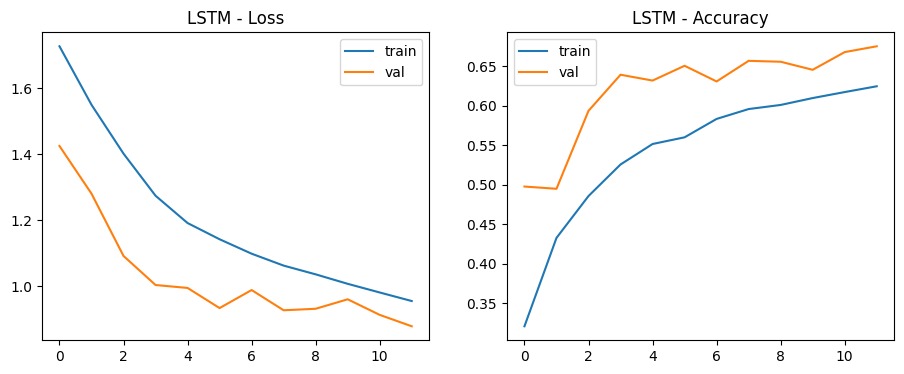

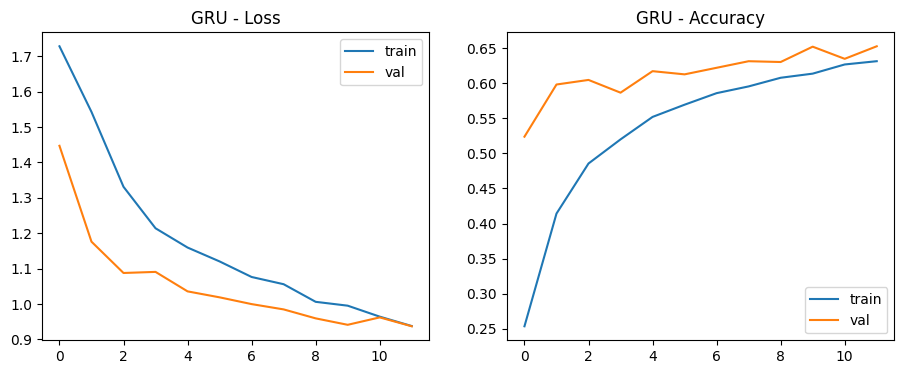

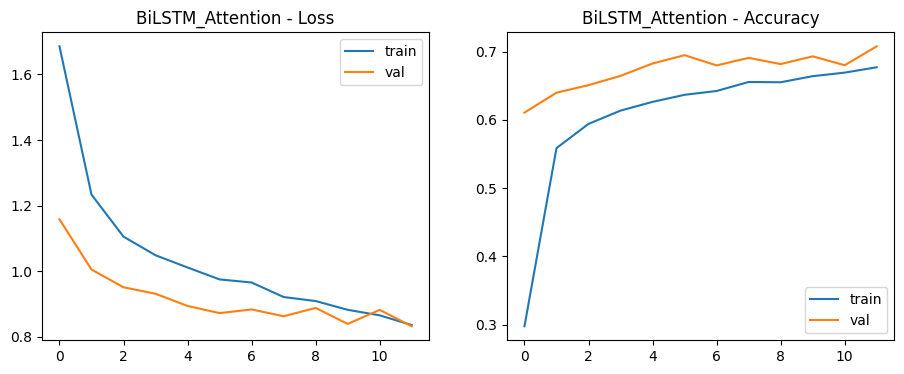

In [24]:
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{name} - Loss"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{name} - Accuracy"); axes[1].legend()
    plt.show()

for name, h in histories.items():
    plot_history(h, name)


##  Evaluation 




===== LSTM =====
Accuracy: 0.6702   Macro F1: 0.5853

              precision    recall  f1-score   support

         joy      0.893     0.734     0.806      1937
     sadness      0.496     0.624     0.553       298
       anger      0.530     0.486     0.507       609
        fear      0.504     0.729     0.596        85
    surprise      0.469     0.660     0.548       533
     disgust      0.391     0.701     0.502        77

    accuracy                          0.670      3539
   macro avg      0.547     0.656     0.585      3539
weighted avg      0.713     0.670     0.683      3539



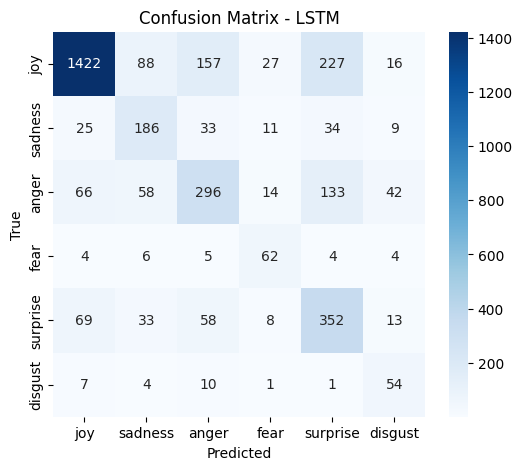


===== GRU =====
Accuracy: 0.6519   Macro F1: 0.5613

              precision    recall  f1-score   support

         joy      0.931     0.687     0.790      1937
     sadness      0.532     0.591     0.560       298
       anger      0.538     0.488     0.512       609
        fear      0.440     0.729     0.549        85
    surprise      0.433     0.722     0.541       533
     disgust      0.289     0.740     0.416        77

    accuracy                          0.652      3539
   macro avg      0.527     0.659     0.561      3539
weighted avg      0.729     0.652     0.671      3539



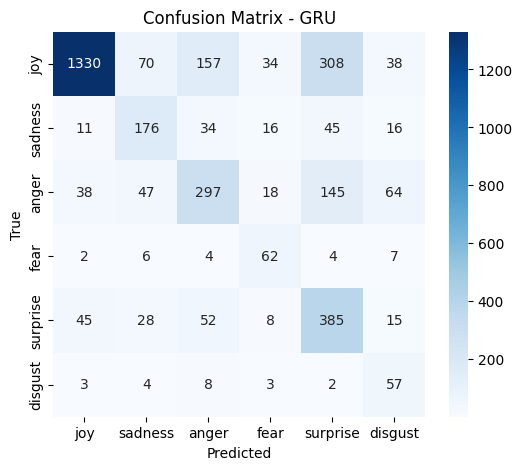


===== BiLSTM + Attention =====
Accuracy: 0.6897   Macro F1: 0.5923

              precision    recall  f1-score   support

         joy      0.899     0.766     0.827      1937
     sadness      0.545     0.584     0.564       298
       anger      0.559     0.555     0.557       609
        fear      0.527     0.800     0.636        85
    surprise      0.502     0.598     0.546       533
     disgust      0.294     0.766     0.424        77

    accuracy                          0.690      3539
   macro avg      0.554     0.678     0.592      3539
weighted avg      0.729     0.690     0.703      3539



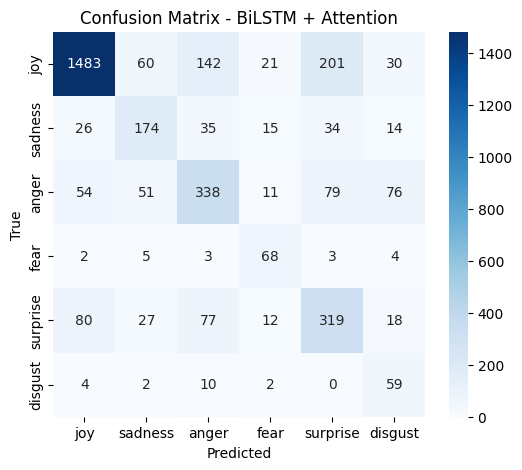

(0.6897428652161628, 0.5922836372758017)

In [25]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

results_summary = {}

def evaluate_keras_model(model, X, y_true, name):
    probs = model.predict(X, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    return evaluate_predictions(y_true, y_pred, name)

def evaluate_predictions(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f}   Macro F1: {macro_f1:.4f}\n")
    # labels=range(NUM_CLASSES) pins report rows to id2label order explicitly,
    # so class names can never get scrambled regardless of how y was encoded.
    ordered_names = [id2label[i] for i in range(NUM_CLASSES)]
    print(classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                 target_names=ordered_names, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=ordered_names, yticklabels=ordered_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.show()

    results_summary[name] = {"accuracy": acc, "macro_f1": macro_f1}
    return acc, macro_f1

evaluate_keras_model(lstm_model, X_test, y_test, "LSTM")
evaluate_keras_model(gru_model, X_test, y_test, "GRU")
evaluate_keras_model(bilstm_attn_model, X_test, y_test, "BiLSTM + Attention")


## . Attention Heatmap Visualization


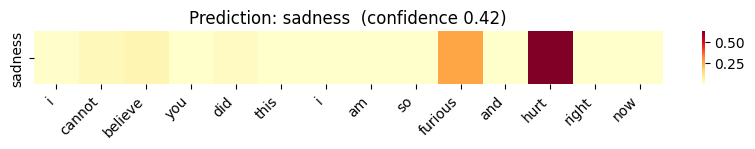

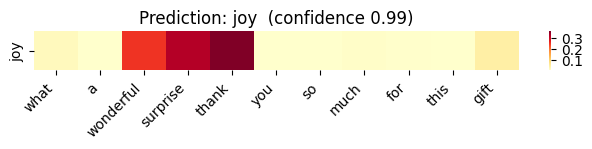

('joy', np.float32(0.9890559))

In [26]:
def visualize_attention(text, model=bilstm_attn_weights_model, tokenizer=tokenizer,
                         max_len=MAX_LEN, class_names=TARGET_EMOTIONS):
    clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    preds, attn = model.predict(padded, verbose=0)
    pred_class = class_names[np.argmax(preds[0])]
    confidence = np.max(preds[0])

    tokens = clean.split()[:max_len]
    weights = attn[0][:len(tokens)]
    weights = weights / (weights.sum() + 1e-9)  # renormalize over real tokens only

    fig, ax = plt.subplots(figsize=(max(6, len(tokens)*0.6), 1.6))
    sns.heatmap(weights.reshape(1, -1), annot=False, cmap="YlOrRd", cbar=True,
                xticklabels=tokens, yticklabels=[pred_class], ax=ax)
    plt.xticks(rotation=45, ha="right")
    plt.title(f'Prediction: {pred_class}  (confidence {confidence:.2f})')
    plt.tight_layout()
    plt.show()
    return pred_class, confidence

# Try it out
visualize_attention("I can't believe you did this, I am so furious and hurt right now")
visualize_attention("What a wonderful surprise, thank you so much for this gift!")


## 9. Fine-tune DistilBERT with HuggingFace


In [27]:
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
import evaluate as hf_evaluate

MODEL_NAME = "distilbert-base-uncased"

# NOTE: id2label / label2id were already defined in section 3 and are reused
# here unchanged, so DistilBERT's class ids match the Keras models exactly.

def to_hf_dataset(df):
    return Dataset.from_dict({
        "text": df["text"].tolist(),
        "label": [label2id[e] for e in df["emotion"]]
    })

hf_dataset = DatasetDict({
    "train": to_hf_dataset(df_train),
    "validation": to_hf_dataset(df_val),
    "test": to_hf_dataset(df_test),
})

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=64)

hf_dataset = hf_dataset.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/28104 [00:00<?, ? examples/s]

Map:   0%|          | 0/3527 [00:00<?, ? examples/s]

Map:   0%|          | 0/3539 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
accuracy_metric = hf_evaluate.load("accuracy")
f1_metric = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": macro_f1}

training_args = TrainingArguments(
    output_dir="./distilbert-emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.171707,1.087229,0.815424,0.676337
2,0.970902,1.028727,0.823363,0.717232
3,0.826350,1.029416,0.828183,0.717058


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1320, training_loss=1.0736012401002826, metrics={'train_runtime': 232.7891, 'train_samples_per_second': 362.182, 'train_steps_per_second': 5.67, 'total_flos': 818949105669024.0, 'train_loss': 1.0736012401002826, 'epoch': 3.0})


===== DistilBERT (fine-tuned) =====
Accuracy: 0.8096   Macro F1: 0.6910

              precision    recall  f1-score   support

         joy      0.915     0.903     0.909      1937
     sadness      0.621     0.664     0.642       298
       anger      0.676     0.718     0.696       609
        fear      0.718     0.659     0.687        85
    surprise      0.747     0.735     0.741       533
     disgust      0.542     0.416     0.471        77

    accuracy                          0.810      3539
   macro avg      0.703     0.683     0.691      3539
weighted avg      0.811     0.810     0.810      3539



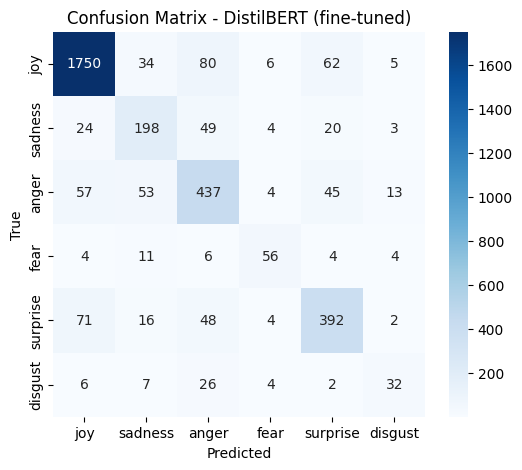

(0.8095507205425262, 0.6910470448745417)

In [30]:
test_predictions = trainer.predict(hf_dataset["test"])
bert_pred_labels = np.argmax(test_predictions.predictions, axis=1)
bert_true_labels = test_predictions.label_ids

evaluate_predictions(bert_true_labels, bert_pred_labels, "DistilBERT (fine-tuned)")


## 10. Compare All Four Models

                         accuracy  macro_f1
DistilBERT (fine-tuned)  0.809551  0.691047
BiLSTM + Attention       0.689743  0.592284
LSTM                     0.670246  0.585338
GRU                      0.651879  0.561287


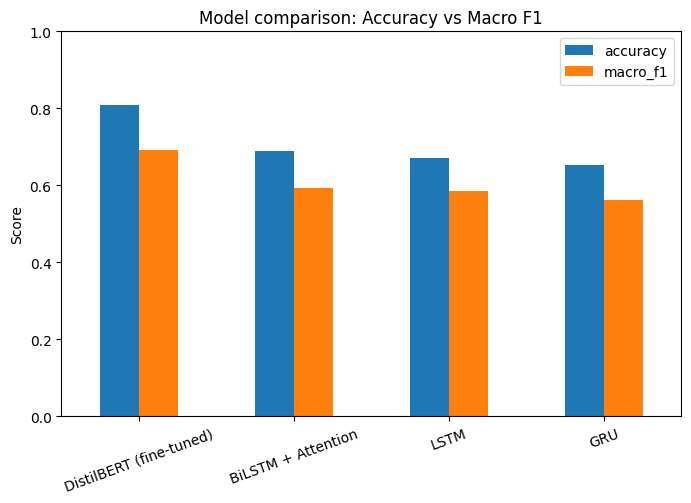

In [31]:
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df.sort_values("macro_f1", ascending=False)
print(summary_df)

summary_df.plot(kind="bar", figsize=(8,5), rot=20)
plt.title("Model comparison: Accuracy vs Macro F1")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


##  Save

In [32]:
import pickle

SAVE_DIR = "/content/emotion_model_export"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Option A: DistilBERT (recommended for the app) ---
trainer.save_model(f"{SAVE_DIR}/distilbert_emotion")
hf_tokenizer.save_pretrained(f"{SAVE_DIR}/distilbert_emotion")

# --- Option B: BiLSTM + Attention (lightweight fallback) ---
bilstm_attn_model.save(f"{SAVE_DIR}/bilstm_attention_model.keras")
with open(f"{SAVE_DIR}/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open(f"{SAVE_DIR}/label_mapping.pkl", "wb") as f:
    pickle.dump({"label2id": label2id, "id2label": id2label}, f)

print("Saved to:", SAVE_DIR)
!ls -la {SAVE_DIR}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/emotion_model_export
total 12324
drwxr-xr-x 3 root root     4096 Jul 23 00:43 .
drwxr-xr-x 1 root root     4096 Jul 23 00:43 ..
-rw-r--r-- 1 root root 11807916 Jul 23 00:43 bilstm_attention_model.keras
drwxr-xr-x 2 root root     4096 Jul 23 00:43 distilbert_emotion
-rw-r--r-- 1 root root      134 Jul 23 00:43 label_mapping.pkl
-rw-r--r-- 1 root root   793073 Jul 23 00:43 tokenizer.pkl


In [33]:
bert_model.save_pretrained("/kaggle/working/distilbert_emotion")
hf_tokenizer.save_pretrained("/kaggle/working/distilbert_emotion")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/distilbert_emotion/tokenizer_config.json',
 '/kaggle/working/distilbert_emotion/tokenizer.json')